# Analyse exploratoire des coordonnées MediaPipe

Objectif du notebook : analyser notre dataste de coordonnées et comprendre si elles contiennent déjà un signal utile pour distinguer les techniques.

In [1]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# StandardScaler
from sklearn.preprocessing import StandardScaler
# PCA 
from sklearn.decomposition import PCA

In [2]:
# Pour afficher les graphiques directement dans le notebook
%matplotlib inline

# Taille par défaut des graphiques
plt.rcParams["figure.figsize"] = (10, 6)

# Style visuel simple
sns.set_theme(style="whitegrid")

## Chargement du fichier CSV

On part du fichier déjà nettoyé : `coordonnees_clean.csv`.


In [3]:
# Chemin vers le fichier de coordonnées
CSV_PATH = "exports/coordonnees_clean.csv"

# Chargement du CSV 
df = pd.read_csv(CSV_PATH)

# Aperçu du dataframe 
df.head()

,nez_x,nez_y,nez_z,nez_vis,oeil_gauche_x,oeil_gauche_y,oeil_gauche_z,oeil_gauche_vis,oeil_droit_x,oeil_droit_y,...,talon_droit_vis,pied_gauche_x,pied_gauche_y,pied_gauche_z,pied_gauche_vis,pied_droit_x,pied_droit_y,pied_droit_z,pied_droit_vis,label
0,0.637621,0.138610,0.233582,0.999896,0.644267,0.119031,0.179639,0.999958,0.651184,0.117968,...,0.991724,0.201480,0.243661,0.067086,0.914758,0.615645,0.909720,0.222452,0.971388,ap_tchagui
1,0.269730,0.257379,-0.114015,0.999281,0.261025,0.242842,-0.074119,0.999220,0.243149,0.248696,...,0.752584,0.644928,0.377261,-0.212476,0.969100,0.617407,0.870777,0.008565,0.859083,ap_tchagui
2,0.561428,0.165053,0.214194,0.999961,0.572796,0.145410,0.166621,0.999978,0.577162,0.146304,...,0.994461,0.176738,0.213497,0.011807,0.989347,0.547044,0.946837,0.178241,0.991011,ap_tchagui
3,0.448500,0.242430,0.075736,0.999923,0.435312,0.229039,0.122694,0.999854,0.425200,0.230837,...,0.983815,0.514320,1.031888,-0.057856,0.992565,0.893744,0.139934,-0.340779,0.990241,ap_tchagui
4,0.468228,0.333009,-0.066888,0.999990,0.475099,0.321822,-0.081985,0.999980,0.475947,0.320622,...,0.971885,0.478222,0.784685,-0.019035,0.995061,0.389568,0.419601,0.124215,0.977637,ap_tchagui


## Analyse du dataset

In [4]:
# Dimensions du dataset 
print("Dimensions du dataset :", df.shape)

# Liste des colonnes 
print("Colonnes :")
print(df.columns.tolist())

# Informations générales 
print("Informations générales :")
df.info()

Dimensions du dataset : (284, 85)
Colonnes :
['nez_x', 'nez_y', 'nez_z', 'nez_vis', 'oeil_gauche_x', 'oeil_gauche_y', 'oeil_gauche_z', 'oeil_gauche_vis', 'oeil_droit_x', 'oeil_droit_y', 'oeil_droit_z', 'oeil_droit_vis', 'oreille_gauche_x', 'oreille_gauche_y', 'oreille_gauche_z', 'oreille_gauche_vis', 'oreille_droite_x', 'oreille_droite_y', 'oreille_droite_z', 'oreille_droite_vis', 'epaule_gauche_x', 'epaule_gauche_y', 'epaule_gauche_z', 'epaule_gauche_vis', 'epaule_droite_x', 'epaule_droite_y', 'epaule_droite_z', 'epaule_droite_vis', 'coude_gauche_x', 'coude_gauche_y', 'coude_gauche_z', 'coude_gauche_vis', 'coude_droit_x', 'coude_droit_y', 'coude_droit_z', 'coude_droit_vis', 'poignet_gauche_x', 'poignet_gauche_y', 'poignet_gauche_z', 'poignet_gauche_vis', 'poignet_droit_x', 'poignet_droit_y', 'poignet_droit_z', 'poignet_droit_vis', 'hanche_gauche_x', 'hanche_gauche_y', 'hanche_gauche_z', 'hanche_gauche_vis', 'hanche_droite_x', 'hanche_droite_y', 'hanche_droite_z', 'hanche_droite_vis', 

## Cible



In [5]:
# Colonne variable cible
TARGET_COL = "label"

print("Colonne cible :", TARGET_COL)
print("Classes présentes :")
print(df[TARGET_COL].value_counts())


Colonne cible : label
Classes présentes :
label
yop_tchagui    146
ap_tchagui     138
Name: count, dtype: int64


## Répartition des classes

Cette étape permet de vérifier si le dataset est équilibré.

Exemple : si on a beaucoup plus de `yop_tchagui` que de `ap_tchagui`, le modèle risque d'être biaisé vers la classe majoritaire.


label
yop_tchagui    146
ap_tchagui     138
Name: count, dtype: int64


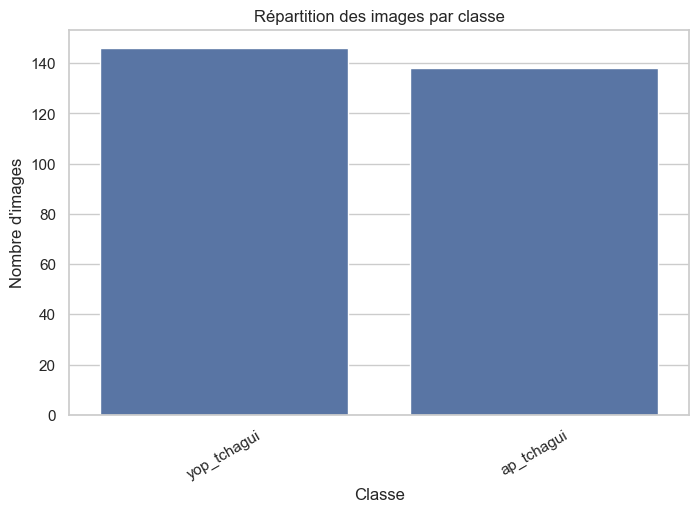

In [6]:
# Comptage du nombre d'images par classe
class_counts = df[TARGET_COL].value_counts()

# Affichage textuel
print(class_counts)

# Visualisation
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COL, order=class_counts.index)
plt.title("Répartition des images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=30)
plt.show()


## Séparer les colonnes numériques


In [7]:
# Sélection des colonnes numériques uniquement
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Si la colonne cible est numérique, on la retire des features
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

# X contient uniquement les variables numériques utilisées pour l'analyse
X = df[numeric_cols].copy()

y = df[TARGET_COL].copy()

print(f"Nombre de variables numériques utilisées : {len(numeric_cols)}")
print("Exemples de colonnes numériques :", numeric_cols[:10])

Nombre de variables numériques utilisées : 84
Exemples de colonnes numériques : ['nez_x', 'nez_y', 'nez_z', 'nez_vis', 'oeil_gauche_x', 'oeil_gauche_y', 'oeil_gauche_z', 'oeil_gauche_vis', 'oeil_droit_x', 'oeil_droit_y']


## Vérification des valeurs manquantes


In [8]:
# Nombre de valeurs manquantes par colonne
missing_values = df.isna().sum().sort_values(ascending=False)

# On garde seulement les colonnes avec au moins une valeur manquante
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("Aucune valeur manquante détectée.")
else:
    print("Colonnes avec valeurs manquantes :")
    display(missing_values)


Aucune valeur manquante détectée.


## Statistiques descriptives

Pour des coordonnées MediaPipe normalisées, les valeurs `x` et `y` sont souvent entre 0 et 1. Les valeurs `z` peuvent être négatives ou positives.


In [9]:
# Statistiques descriptives 
X.describe().T

,count,mean,std,min,25%,50%,75%,max
nez_x,284.0,0.502669,0.222964,0.010944,0.306397,0.528817,0.678660,0.968384
nez_y,284.0,0.250347,0.092966,0.041880,0.180978,0.243331,0.309948,0.583543
nez_z,284.0,-0.214933,0.286753,-1.160210,-0.402600,-0.250432,-0.041681,0.744100
nez_vis,284.0,0.998671,0.004323,0.960170,0.999453,0.999868,0.999953,0.999997
oeil_gauche_x,284.0,0.508263,0.233897,0.018283,0.295872,0.531834,0.694850,0.991102
...,...,...,...,...,...,...,...,...
pied_gauche_vis,284.0,0.867862,0.207739,0.078934,0.899335,0.960472,0.984169,0.998697
pied_droit_x,284.0,0.433681,0.196599,-0.045112,0.290939,0.427712,0.554857,0.975722
pied_droit_y,284.0,0.599078,0.350406,-0.182546,0.225263,0.723433,0.927274,1.070387
pied_droit_z,284.0,-0.131565,0.251971,-1.093925,-0.301286,-0.138004,0.036858,0.659778


## Détection de valeurs extrêmes

In [10]:
# Résumé min / max pour chaque variable numérique
min_max_summary = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "mean": X.mean(),
    "std": X.std()
}).sort_values("std", ascending=False)

# Affichage des 20 variables avec la plus forte dispersion
min_max_summary.head(20)

,min,max,mean,std
pied_gauche_y,-0.072014,1.126384,0.559274,0.353157
pied_droit_y,-0.182546,1.070387,0.599078,0.350406
poignet_gauche_z,-1.210515,0.753342,-0.244444,0.337924
poignet_droit_z,-1.404995,0.622107,-0.207368,0.327646
coude_gauche_vis,0.015859,0.998902,0.726388,0.318900
coude_droit_vis,0.047281,0.995697,0.674821,0.315309
talon_gauche_y,0.018822,1.126139,0.577209,0.310848
talon_droit_y,-0.034163,1.052370,0.616073,0.308996
poignet_gauche_vis,0.011175,0.995658,0.681966,0.303298
cheville_gauche_y,0.031478,1.092118,0.562964,0.299765


## Analyse des distributions

On visualise la distribution de quelques variables numériques.

L'idée est de voir si certaines coordonnées semblent déjà différencier les classes.

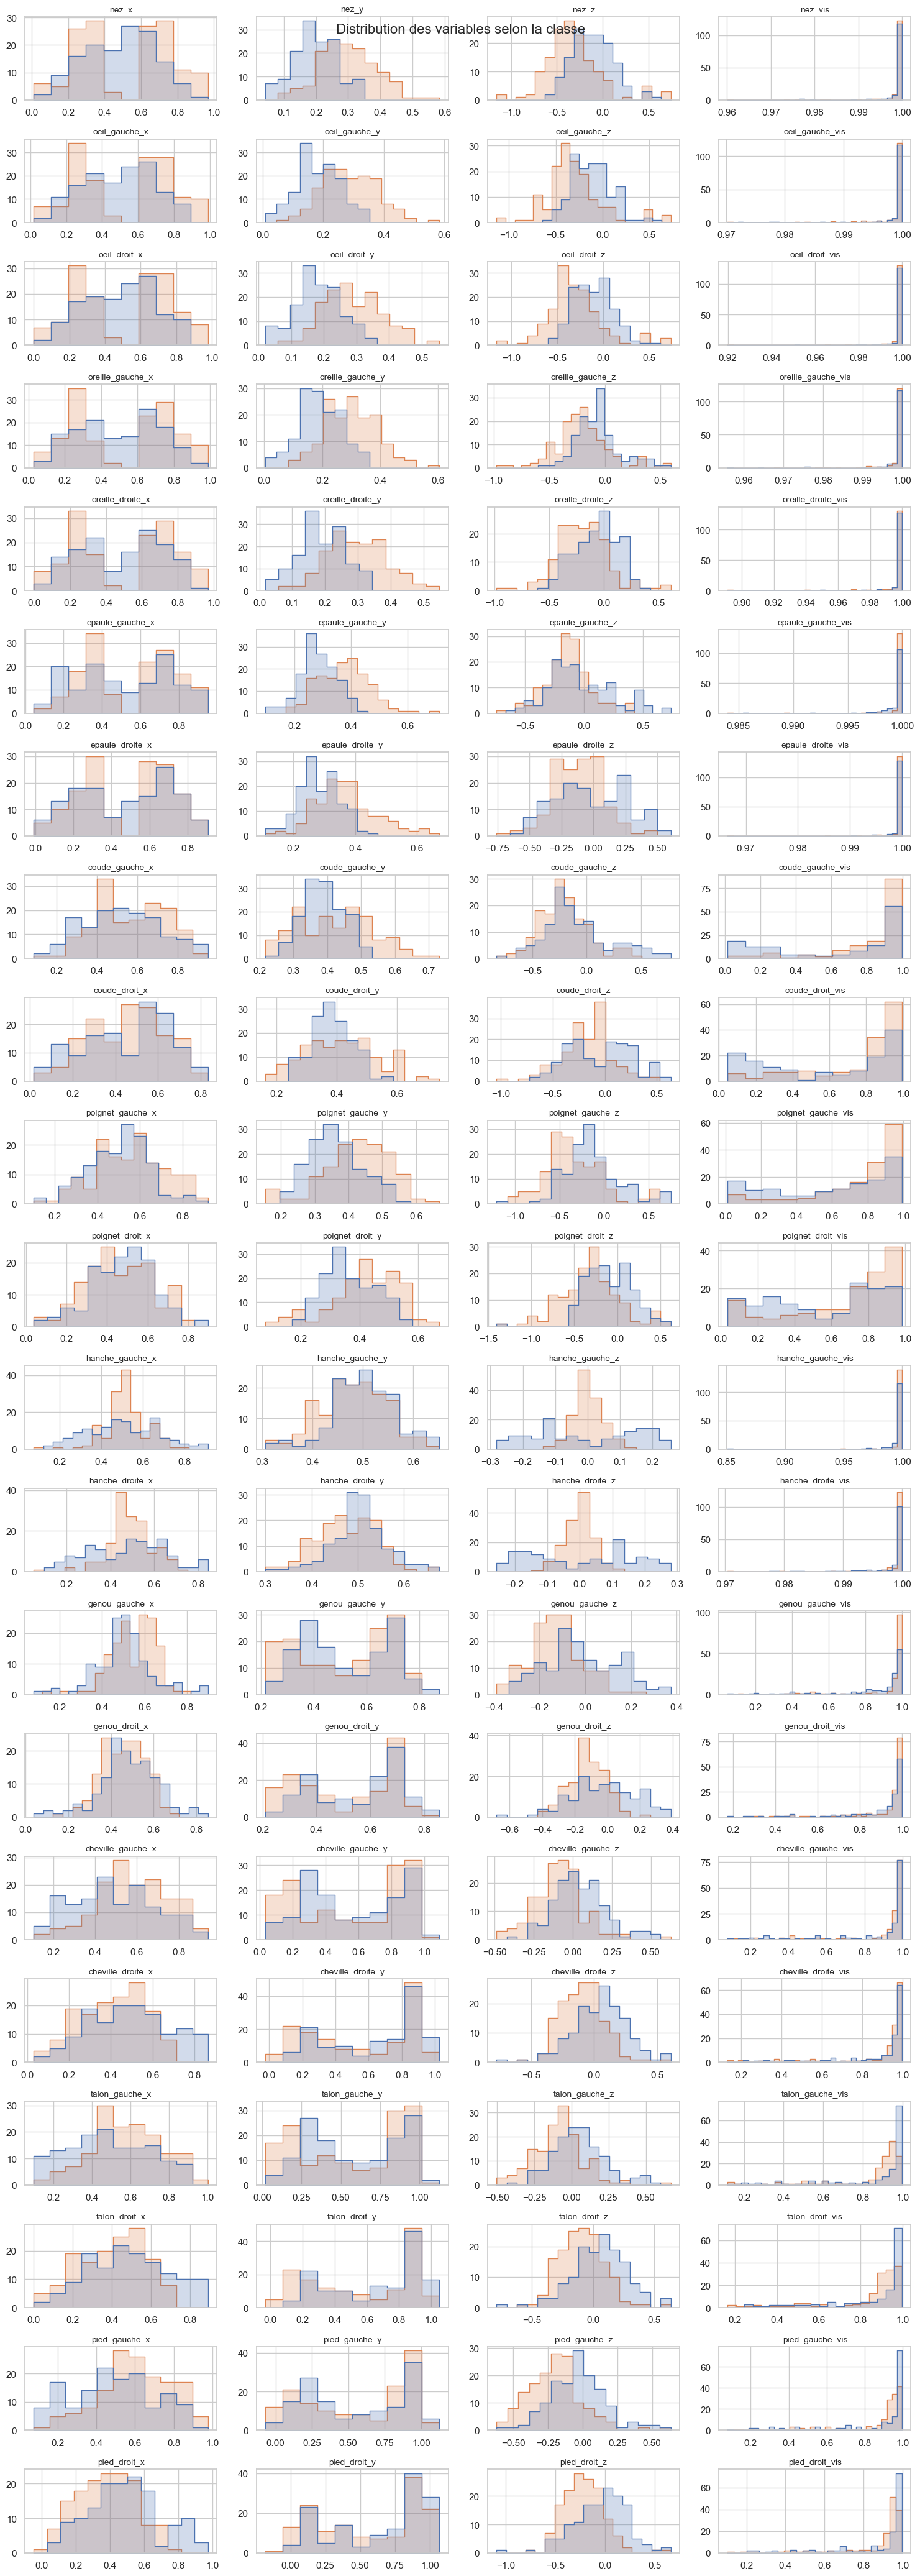

In [11]:
import math

# Colonnes à afficher
cols_to_plot = numeric_cols[:84]

# Paramètres de la grille
n_cols = 4
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 2 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cols_to_plot):

    sns.histplot(
        data=df,
        x=col,
        hue=TARGET_COL,
        element="step",
        stat="count",
        kde=False,
        ax=axes[i]
    )

    # Suppression de la légende
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Suppression des cases vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution des variables selon la classe",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Corrélation entre variables

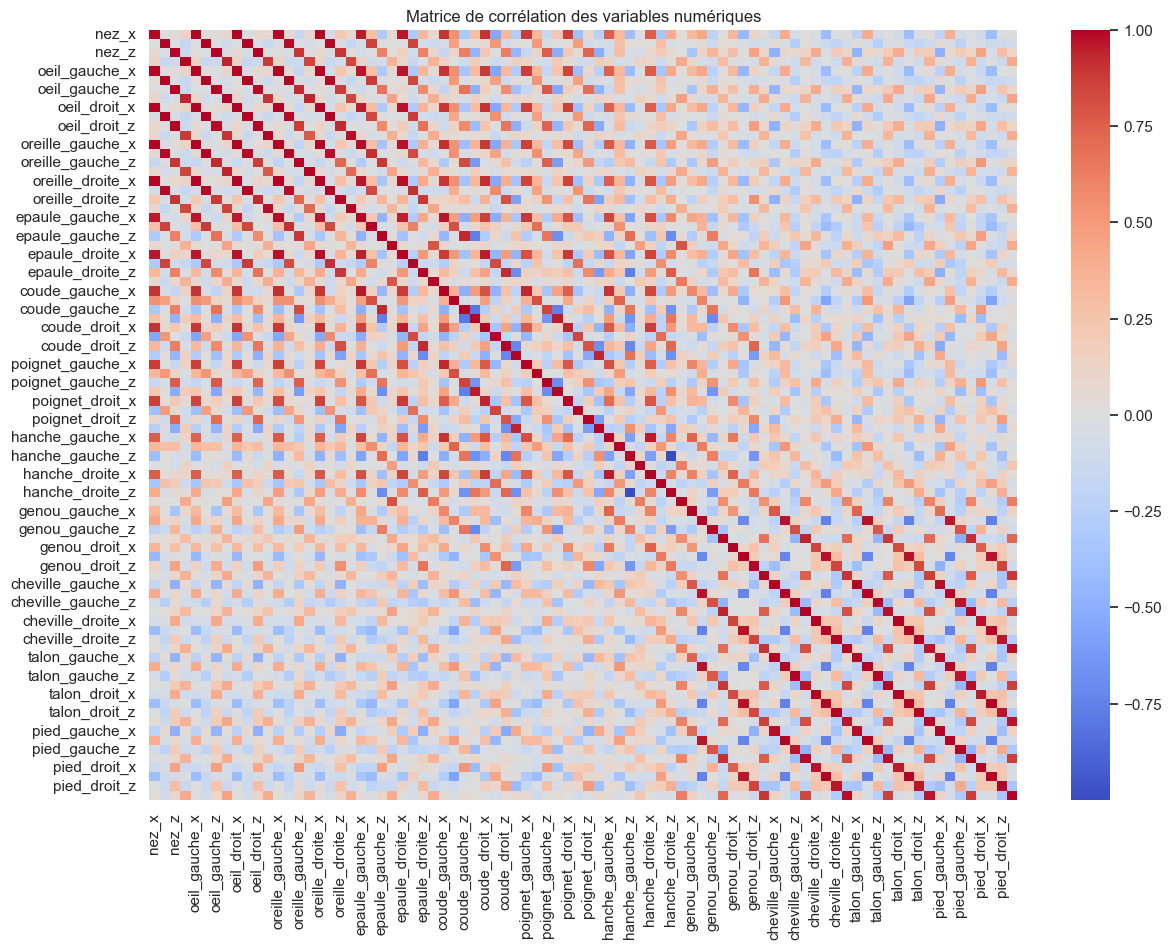

In [12]:
# Calcul de la matrice de corrélation sur les variables numériques
corr_matrix = X.corr()

# Affichage de la heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()


## Variables très corrélées

On extrait les paires de variables dont la corrélation absolue est supérieure à un seuil.

Par défaut, on met `0.90`, ce qui signifie : très forte corrélation.


In [13]:
# Seuil de corrélation forte
CORR_THRESHOLD = 0.90

# On récupère seulement le triangle supérieur de la matrice (cela évite d'avoir deux fois la même paire)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Liste des paires fortement corrélées
high_corr_pairs = []

for col in upper_triangle.columns:
    correlated_cols = upper_triangle.index[upper_triangle[col].abs() > CORR_THRESHOLD].tolist()
    for row in correlated_cols:
        high_corr_pairs.append({
            "variable_1": row,
            "variable_2": col,
            "correlation": upper_triangle.loc[row, col]
        })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("correlation", key=abs, ascending=False)

print(f"Nombre de paires avec |corrélation| > {CORR_THRESHOLD} : {len(high_corr_df)}")
high_corr_df.head(30)


Nombre de paires avec |corrélation| > 0.9 : 90


,variable_1,variable_2,correlation
56,hanche_gauche_z,hanche_droite_z,-0.999996
63,cheville_gauche_y,talon_gauche_y,0.999409
68,cheville_droite_y,talon_droit_y,0.999245
69,cheville_droite_z,talon_droit_z,0.999120
4,nez_x,oeil_droit_x,0.999102
5,oeil_gauche_x,oeil_droit_x,0.998965
0,nez_x,oeil_gauche_x,0.998935
64,cheville_gauche_z,talon_gauche_z,0.998713
1,nez_y,oeil_gauche_y,0.997402
6,nez_y,oeil_droit_y,0.997223
